Columns: Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no   

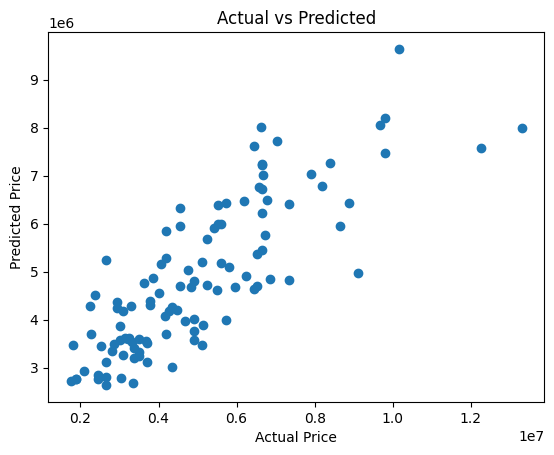


Sample Prediction: 5158352.077718235


In [8]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv('Housing.csv')

# ==============================
# 3. DATA UNDERSTANDING
# ==============================
print("Columns:", df.columns)
print(df.head())

# ==============================
# 4. DATA CLEANING
# ==============================
# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# ==============================
# 5. FEATURE ENGINEERING (SAFE)
# ==============================
if all(col in df.columns for col in ['total_rooms', 'households']):
    df['rooms_per_household'] = df['total_rooms'] / df['households']

if all(col in df.columns for col in ['total_bedrooms', 'total_rooms']):
    df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

if all(col in df.columns for col in ['population', 'households']):
    df['population_per_household'] = df['population'] / df['households']

if all(col in df.columns for col in ['area', 'bedrooms']):
    df['area_per_bedroom'] = df['area'] / df['bedrooms']

# ==============================
# 6. HANDLE CATEGORICAL DATA
# ==============================
df = pd.get_dummies(df, drop_first=True)

# ==============================
# 7. SELECT TARGET COLUMN (AUTO)
# ==============================
possible_targets = ['price', 'Price', 'median_house_value', 'target']

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise Exception("No valid target column found. Rename your price column.")

print("Target Column:", target_col)

# ==============================
# 8. SPLIT DATA
# ==============================
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 9. FEATURE SCALING
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 10. MODEL TRAINING
# ==============================
model = LinearRegression()
model.fit(X_train, y_train)

# ==============================
# 11. PREDICTION
# ==============================
y_pred = model.predict(X_test)

# ==============================
# 12. EVALUATION
# ==============================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==============================
# 13. ACTUAL VS PREDICTED
# ==============================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

# ==============================
# 14. SINGLE PREDICTION
# ==============================
sample = X_test[0].reshape(1, -1)
predicted_price = model.predict(sample)

print("\nSample Prediction:", predicted_price[0])